In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (25000, 15)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


In [2]:
print(df.columns.tolist())

['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost']


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

Duplicate rows:
0

Data types:
delivery_id            float64
delivery_partner        object
package_type            object
vehicle_type            object
delivery_mode           object
region                  object
weather_condition       object
distance_km            float64
package_weight_kg      float64
delivery_time_hours     object
expected_time_hours     object
delayed                 object
delivery_status         object
delivery_rating          int64
delivery_cost          float64
dtype: object


In [4]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (25000, 15)


In [5]:
df["delivery_time_hours"] = pd.to_datetime(
    df["delivery_time_hours"]
).dt.nanosecond.astype(float)

df["expected_time_hours"] = pd.to_datetime(
    df["expected_time_hours"]
).dt.nanosecond.astype(float)

In [6]:
df[
    ["delivery_time_hours", "expected_time_hours"]
].head(10)

,delivery_time_hours,expected_time_hours
0,8.0,8.0
1,2.0,3.0
2,10.0,16.0
3,6.0,8.0
4,9.0,16.0
5,4.0,2.0
6,6.0,8.0
7,4.0,8.0
8,5.0,8.0
9,3.0,8.0


In [7]:
df["Delay_Duration_Hours"] = (
    df["delivery_time_hours"] -
    df["expected_time_hours"]
)

In [8]:
df[
    [
        "delivery_time_hours",
        "expected_time_hours",
        "Delay_Duration_Hours"
    ]
].head(10)

,delivery_time_hours,expected_time_hours,Delay_Duration_Hours
0,8.0,8.0,0.0
1,2.0,3.0,-1.0
2,10.0,16.0,-6.0
3,6.0,8.0,-2.0
4,9.0,16.0,-7.0
5,4.0,2.0,2.0
6,6.0,8.0,-2.0
7,4.0,8.0,-4.0
8,5.0,8.0,-3.0
9,3.0,8.0,-5.0


In [9]:
print(df["delayed"].value_counts())

delayed
no     18331
yes     6669
Name: count, dtype: int64


In [10]:
print(
    df["delayed"]
    .value_counts(normalize=True) * 100
)

delayed
no     73.324
yes    26.676
Name: proportion, dtype: float64


In [11]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost,Delay_Duration_Hours
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,6.248040,13.107680,3.666000,864.944579,-6.859640
std,7212.732314,86.409745,14.368663,3.140935,7.559024,1.149964,435.712593,8.069482
min,250.990000,3.600000,0.670000,0.000000,2.000000,1.000000,95.667400,-24.000000
25%,6250.750000,75.900000,12.680000,4.000000,8.000000,3.000000,490.800000,-14.000000
50%,12500.500000,151.000000,25.145000,6.000000,8.000000,4.000000,867.535000,-6.000000
75%,18750.250000,224.900000,37.660000,8.000000,16.000000,5.000000,1237.910000,0.000000
max,24750.010000,297.100000,49.520000,19.000000,24.000000,5.000000,1632.720600,12.000000


In [12]:
df[
    [
        "distance_km",
        "package_weight_kg",
        "delivery_time_hours",
        "expected_time_hours",
        "Delay_Duration_Hours",
        "delivery_cost",
        "delivery_rating"
    ]
].describe()

,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,Delay_Duration_Hours,delivery_cost,delivery_rating
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,150.390436,25.145898,6.248040,13.107680,-6.859640,864.944579,3.666000
std,86.409745,14.368663,3.140935,7.559024,8.069482,435.712593,1.149964
min,3.600000,0.670000,0.000000,2.000000,-24.000000,95.667400,1.000000
25%,75.900000,12.680000,4.000000,8.000000,-14.000000,490.800000,3.000000
50%,151.000000,25.145000,6.000000,8.000000,-6.000000,867.535000,4.000000
75%,224.900000,37.660000,8.000000,16.000000,0.000000,1237.910000,5.000000
max,297.100000,49.520000,19.000000,24.000000,12.000000,1632.720600,5.000000


In [13]:
categorical_columns = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "delayed",
    "delivery_status"
]

for col in categorical_columns:
    print("\n====================")
    print(col)
    print("====================")
    print(df[col].value_counts())


delivery_partner
delivery_partner
xpressbees          2826
fedex               2818
dhl                 2802
ekart               2801
blue dart           2798
delhivery           2786
shadowfax           2736
ecom express        2722
amazon logistics    2711
Name: count, dtype: int64

package_type
package_type
fragile items       2848
pharmacy            2810
documents           2805
automobile parts    2795
electronics         2792
clothing            2767
furniture           2746
cosmetics           2744
groceries           2693
Name: count, dtype: int64

vehicle_type
vehicle_type
ev bike    4218
van        4187
scooter    4174
bike       4160
truck      4145
ev van     4116
Name: count, dtype: int64

delivery_mode
delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64

region
region
west       5095
central    5060
south      4977
north      4949
east       4919
Name: count, dtype: int64

weather_condition
weather_condition
foggy 

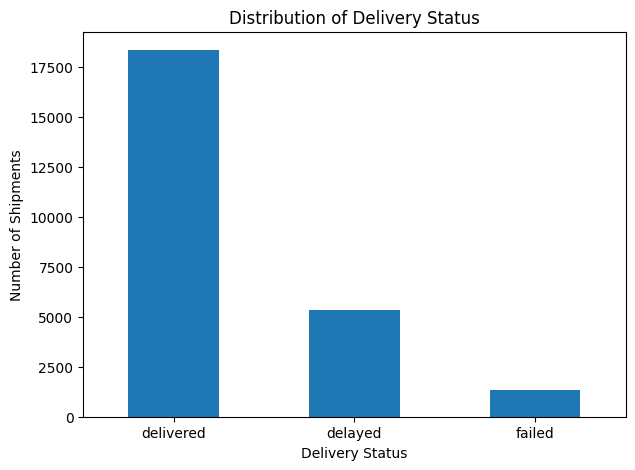

In [14]:
plt.figure(figsize=(7,5))

df["delivery_status"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)

plt.show()

In [15]:
mode_analysis = df.groupby(
    "delivery_mode"
)["delivery_time_hours"].agg(
    ["mean", "median", "count"]
).sort_values(
    "mean",
    ascending=False
)

print(mode_analysis)

                   mean  median  count
delivery_mode                         
two day        6.278642     6.0   6302
same day       6.244784     6.0   6279
standard       6.237472     6.0   6186
express        6.230868     6.0   6233


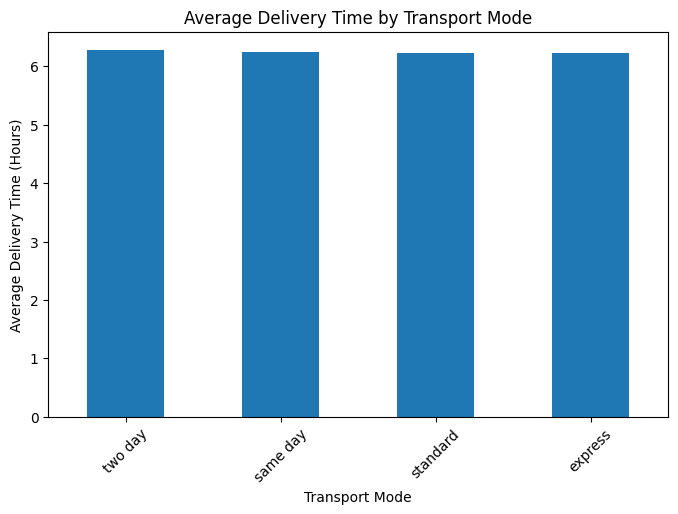

In [16]:
plt.figure(figsize=(8,5))

mode_analysis["mean"].plot(kind="bar")

plt.title("Average Delivery Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Delivery Time (Hours)")
plt.xticks(rotation=45)

plt.show()

In [17]:
partner_analysis = df.groupby(
    "delivery_partner"
).agg(
    Average_Delivery_Time=("delivery_time_hours", "mean"),
    Average_Delay=("Delay_Duration_Hours", "mean"),
    Shipment_Volume=("delivery_id", "count"),
    Delay_Rate=("delayed", lambda x: (x == "yes").mean() * 100)
).sort_values(
    "Average_Delay",
    ascending=False
)

print(partner_analysis)

                  Average_Delivery_Time  Average_Delay  Shipment_Volume  \
delivery_partner                                                          
blue dart                      6.296283      -6.709078             2798   
xpressbees                     6.323779      -6.716914             2826   
ekart                          6.268119      -6.720100             2801   
shadowfax                      6.272295      -6.779605             2736   
ecom express                   6.246877      -6.837987             2722   
amazon logistics               6.279233      -6.840649             2711   
fedex                          6.140880      -6.937899             2818   
dhl                            6.250535      -6.951820             2802   
delhivery                      6.155420      -7.242283             2786   

                  Delay_Rate  
delivery_partner              
blue dart          26.947820  
xpressbees         28.273178  
ekart              27.418779  
shadowfax          

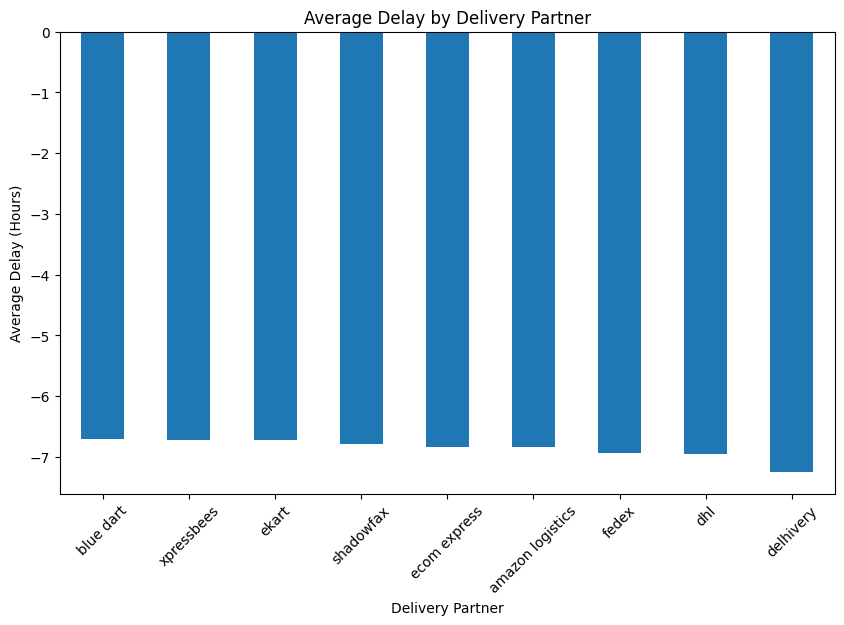

In [18]:
plt.figure(figsize=(10,6))

partner_analysis["Average_Delay"].plot(
    kind="bar"
)

plt.title("Average Delay by Delivery Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Average Delay (Hours)")
plt.xticks(rotation=45)

plt.show()

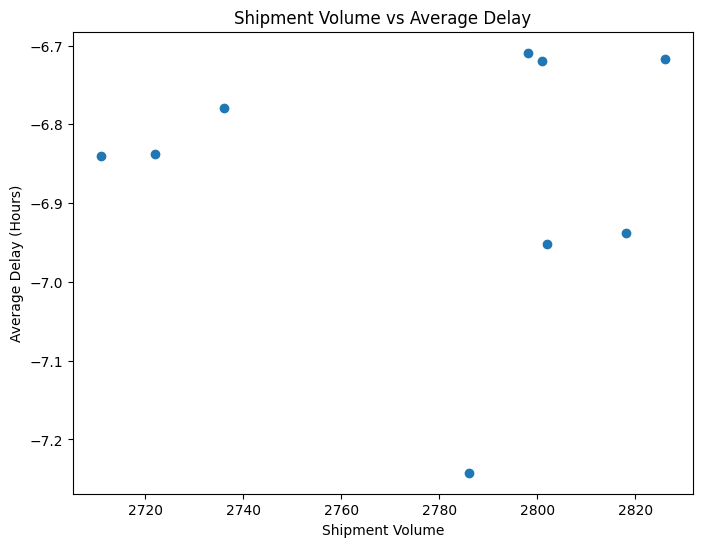

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    partner_analysis["Shipment_Volume"],
    partner_analysis["Average_Delay"]
)

plt.title("Shipment Volume vs Average Delay")
plt.xlabel("Shipment Volume")
plt.ylabel("Average Delay (Hours)")

plt.show()

In [20]:
correlation = partner_analysis[
    ["Shipment_Volume", "Average_Delay"]
].corr()

print(correlation)

                 Shipment_Volume  Average_Delay
Shipment_Volume         1.000000      -0.020126
Average_Delay          -0.020126       1.000000


In [21]:
print("Partner with highest average delay:")

print(
    partner_analysis[
        "Average_Delay"
    ].idxmax()
)

print(
    "Average delay:",
    partner_analysis[
        "Average_Delay"
    ].max(),
    "hours"
)

Partner with highest average delay:
blue dart
Average delay: -6.709077912794854 hours


In [22]:
print("Partner with highest delay rate:")

print(
    partner_analysis[
        "Delay_Rate"
    ].idxmax()
)

print(
    "Delay rate:",
    partner_analysis[
        "Delay_Rate"
    ].max(),
    "%"
)

Partner with highest delay rate:
xpressbees
Delay rate: 28.27317763623496 %


In [23]:
weather_analysis = df.groupby(
    "weather_condition"
).agg(
    Average_Delivery_Time=("delivery_time_hours", "mean"),
    Average_Delay=("Delay_Duration_Hours", "mean"),
    Delay_Rate=("delayed", lambda x: (x == "yes").mean() * 100)
).sort_values(
    "Average_Delay",
    ascending=False
)

print(weather_analysis)

                   Average_Delivery_Time  Average_Delay  Delay_Rate
weather_condition                                                  
stormy                          8.807527      -4.343735   41.448309
rainy                           7.804843      -5.361304   37.353153
foggy                           6.486608      -6.826499   30.315241
clear                           4.776431      -8.105723   17.434530
hot                             4.784504      -8.228329   17.118644
cold                            4.773449      -8.341029   16.017316


In [24]:
region_analysis = df.groupby(
    "region"
).agg(
    Average_Delivery_Time=("delivery_time_hours", "mean"),
    Average_Delay=("Delay_Duration_Hours", "mean"),
    Shipment_Volume=("delivery_id", "count"),
    Delay_Rate=("delayed", lambda x: (x == "yes").mean() * 100)
).sort_values(
    "Average_Delay",
    ascending=False
)

print(region_analysis)

         Average_Delivery_Time  Average_Delay  Shipment_Volume  Delay_Rate
region                                                                    
west                  6.296369      -6.776447             5095   26.947988
central               6.283004      -6.782213             5060   27.252964
south                 6.196102      -6.886076             4977   26.783203
north                 6.249141      -6.925439             4949   26.571024
east                  6.213458      -6.932507             4919   25.797926


In [25]:
vehicle_analysis = df.groupby(
    "vehicle_type"
).agg(
    Average_Delivery_Time=("delivery_time_hours", "mean"),
    Average_Delay=("Delay_Duration_Hours", "mean"),
    Delay_Rate=("delayed", lambda x: (x == "yes").mean() * 100)
).sort_values(
    "Average_Delay",
    ascending=False
)

print(vehicle_analysis)

              Average_Delivery_Time  Average_Delay  Delay_Rate
vehicle_type                                                  
ev bike                    6.197013      -6.747274   26.434329
scooter                    6.278869      -6.796119   26.137997
bike                       6.277644      -6.841827   27.043269
truck                      6.217129      -6.903739   27.044632
ev van                     6.250000      -6.913994   26.627794
van                        6.267972      -6.956771   26.773346


In [26]:
df["Delayed_Target"] = df["delayed"].map({
    "no": 0,
    "yes": 1
})

In [27]:
print(df["Delayed_Target"].value_counts())

Delayed_Target
0    18331
1     6669
Name: count, dtype: int64


In [28]:
features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "distance_km",
    "package_weight_kg",
    "expected_time_hours",
    "delivery_cost"
]

X = df[features]
y = df["Delayed_Target"]

In [29]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost']
Categorical: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (20000, 10)
Testing: (5000, 10)


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [33]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf)
    ]
)

In [34]:
model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [35]:
y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_probability))

Accuracy : 0.8926
Precision: 0.793662490788504
Recall   : 0.8073463268365817
F1 Score : 0.8004459308807135
ROC-AUC  : 0.9648431717038373


In [37]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["On Time", "Delayed"]
    )
)

              precision    recall  f1-score   support

     On Time       0.93      0.92      0.93      3666
     Delayed       0.79      0.81      0.80      1334

    accuracy                           0.89      5000
   macro avg       0.86      0.87      0.86      5000
weighted avg       0.89      0.89      0.89      5000



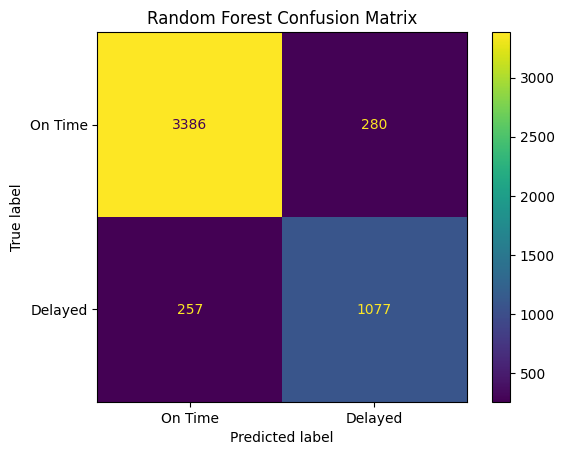

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["On Time", "Delayed"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [39]:
feature_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                          Feature  Importance
2        num__expected_time_hours    0.229758
28     cat__delivery_mode_express    0.157806
30    cat__delivery_mode_standard    0.091018
3              num__delivery_cost    0.080467
31     cat__delivery_mode_two day    0.077273
0                num__distance_km    0.075300
1          num__package_weight_kg    0.042148
29    cat__delivery_mode_same day    0.035322
42  cat__weather_condition_stormy    0.021604
38    cat__weather_condition_cold    0.013425
40     cat__weather_condition_hot    0.012085
41   cat__weather_condition_rainy    0.011643
37   cat__weather_condition_clear    0.011138
39   cat__weather_condition_foggy    0.005959
36               cat__region_west    0.005578


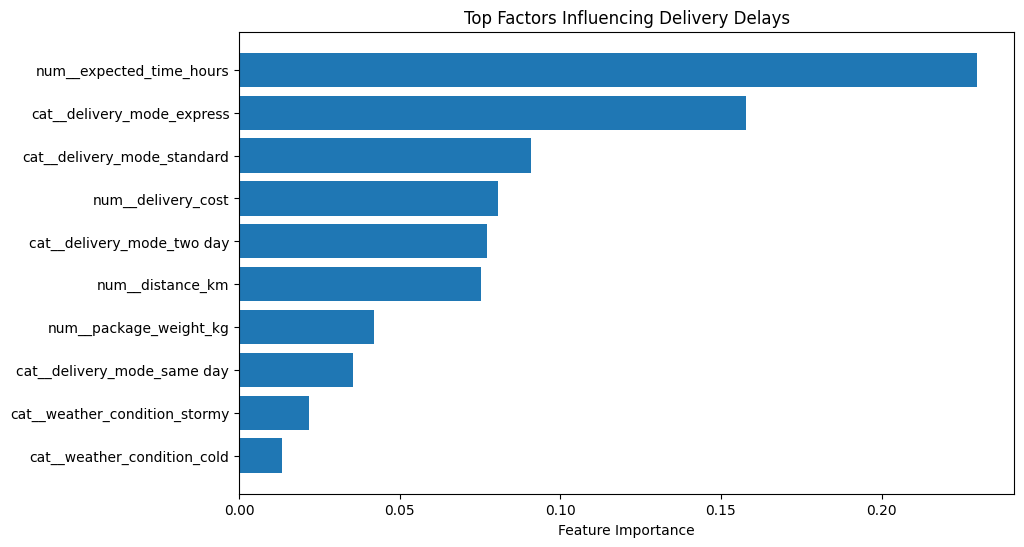

In [40]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top Factors Influencing Delivery Delays")
plt.xlabel("Feature Importance")

plt.show()

In [41]:
partner_analysis.to_csv(
    "delivery_partner_bottleneck_analysis.csv"
)

In [42]:
priority_list = X_test.copy()

priority_list["Actual_Delayed"] = y_test.values
priority_list["Predicted_Delayed"] = y_pred
priority_list["Delay_Probability"] = y_probability

In [43]:
priority_list["delivery_id"] = df.loc[
    X_test.index,
    "delivery_id"
].values

In [44]:
priority_list = priority_list.sort_values(
    "Delay_Probability",
    ascending=False
)

In [45]:
priority_list[
    [
        "delivery_id",
        "delivery_partner",
        "delivery_mode",
        "region",
        "weather_condition",
        "distance_km",
        "Delay_Probability",
        "Predicted_Delayed"
    ]
].head(20)

,delivery_id,delivery_partner,delivery_mode,region,weather_condition,distance_km,Delay_Probability,Predicted_Delayed
21545,21546.00,dhl,express,central,stormy,75.5,1.000,1
10357,10358.00,fedex,express,north,rainy,94.1,1.000,1
16142,16143.00,blue dart,express,north,stormy,263.9,1.000,1
6301,6302.00,delhivery,express,east,stormy,169.3,1.000,1
24665,24666.00,xpressbees,express,south,stormy,176.0,1.000,1
11311,11312.00,blue dart,express,east,stormy,75.7,1.000,1
10407,10408.00,fedex,express,west,stormy,134.5,1.000,1
17263,17264.00,fedex,express,west,stormy,165.6,0.995,1
21658,21659.00,ecom express,express,west,stormy,79.5,0.995,1
1718,1719.00,dhl,express,west,stormy,69.9,0.995,1


In [46]:
def assign_priority(probability):
    if probability >= 0.80:
        return "High"
    elif probability >= 0.50:
        return "Medium"
    else:
        return "Low"

priority_list["Priority"] = (
    priority_list["Delay_Probability"]
    .apply(assign_priority)
)

In [47]:
priority_list.to_csv(
    "prioritized_delay_list.csv",
    index=False
)

print("Final delay-priority list saved.")

Final delay-priority list saved.
